#### Import Libraries

In [2]:
import os
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.runnables.graph import MermaidDrawMethod
import json
from typing import TypedDict, Annotated, List
from pydantic import Field, BaseModel
from langchain_core.prompts import ChatPromptTemplate
import asyncio
import nest_asyncio
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
nest_asyncio.apply()
from concurrent.futures import ThreadPoolExecutor
from langgraph.graph import StateGraph, START, END     
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage

load_dotenv()

/var/folders/5n/yqyldx8x7pq7k88nq5xsfpyw0000gn/T/ipykernel_67099/1136542409.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


True

#### Initialize LLM using OPENAI_API_KEY

In [3]:
if(os.getenv("OPENAI_API_KEY")):
    print("OPENAI Key initialized")
else:
    raise AttributeError("OPENAI Key not initialized")

OPENAI Key initialized


In [4]:
llm = ChatOpenAI(
    model = "gpt-4o-mini",
    temperature = 0.5,
    api_key = os.getenv("OPENAI_API_KEY")
)

##### LLM Schema for structured results
###### query_schema: To get a list of queries for web search
###### planner_schema: To generate plan for final report

In [5]:
class query_schema(BaseModel):
    input_queries: List[str] = Field(description = "List of queries about the input from user")
llm_for_queries = llm.with_structured_output(query_schema)

In [6]:
class planner_schema(BaseModel):
    sections: List[str] = Field(description="Sections of the final report to generate")
    section_reasoning: List[str] = Field(description="Reasoning to write the section, specify what to write in each section")
llm_for_planner = llm.with_structured_output(planner_schema)

#### State for StateGraph 

In [7]:
class State(TypedDict):
    topic: str = Field(description="Topic of research")
    messages: Annotated[List, add_messages]
    input_queries: List[str] = Field(description = "List of queries about the input from user")
    execution_stage: int = Field(description= "Signify if the execution is in planning stage of implementation stage")
    sections: List[str] = Field(description="Sections of the final report to generate")
    section_reasoning: List[str] = Field(description="Reasoning to write the section, specify what to write in each section") 
    current_section : int = Field(description="Current section to generate, used for graph loop")
    report: str = Field(description="Final Report")

#### RAG
##### Functions to Initialize RAG, Add new documents and fetch documents using similarity search

In [8]:
def initialize_rag(text:str, metadata:dict, persist_dir: str):
    docs = [Document(page_content = text, metadata = metadata)]
    
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = 1000,
        chunk_overlap = 300
    )
    chunks = text_splitter.split_documents(docs)
    
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=persist_dir
    )

In [9]:
def add_docs_to_rag(text:str, metadata:dict, persist_dir:str):
    embeddings = OpenAIEmbeddings()
    
    vector_store = Chroma(
        persist_directory=persist_dir,
        embedding_function=embeddings
    )
    
    docs = [Document(page_content = text, metadata = metadata)]
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = 1000,
        chunk_overlap = 300
    )
    chunks = text_splitter.split_documents(docs)
    
    vector_store.add_documents(chunks)

In [10]:
def fetch_rag(query:str, metadata:dict)-> List:
    """Use this if you need additional context about writing the research report

    Args:
        query (str): Query to fetch data from RAG
        metadata (dict): use {"tag": "all"} or {"tag": f"{section_name}} to get section related data

    Returns:
        _type_: List of documents fetched from RAG
    """
    embeddings = OpenAIEmbeddings()
    vector_store = Chroma(
        persist_directory="./vector_store",
        embedding_function=embeddings
    )
    results = vector_store.similarity_search(
            query=query,
            k=1,
            filter=metadata
        )
    return results

In [11]:
tool_by_name = {"fetch_rag": fetch_rag}

#### Nodes

In [12]:
def query_generator(state: State) -> State: 
    '''
    Langgraph Node to Generate a list of queries to better understand the research topic.
    '''   
    initialize_rag("Initialize RAG", {"tag": "init"}, "./vector_store")
    prompt = [HumanMessage(content = f"Generate a list of queries (maximum 5) for better understanding of {state['topic']}.")]
    state["messages"] = prompt
    
    response = llm_for_queries.invoke(state["messages"])
    
    
    state["input_queries"] = response.input_queries
    state["messages"] = [AIMessage(content = response.input_queries)]
    
    return state

In [13]:
import os
async def fetch_mcp_search(query):
    server_params = StdioServerParameters(
        command="python3",
        args=["duckduckgo_mcp_server.py"],
        env=os.environ.copy()
    )
    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            tools = await load_mcp_tools(session)
            search_tool = next((t for t in tools if t.name == "duckduckgo_search"), None)
            if search_tool:
                try:
                    res = await search_tool.ainvoke({"query": query})
                    return str(res)
                except Exception as e:
                    return f"MCP Tool Error: {e}"
            return ""

def search(query:str)-> str:
    try:
        return asyncio.run(fetch_mcp_search(query))
    except Exception as e:
        print(f"MCP Async Error: {e}")
        return ""

def web_search(state:State) -> State: 
    '''
    Langgraph Node to seach the web for answers of queries, to better understand the research topic.
    '''        
    tasks = state["input_queries"]
    if(state["execution_stage"] != 1):
        current_section = state["sections"][state["current_section"]]
    results = []
    with ThreadPoolExecutor() as executor:
        result_futures = executor.map(search, tasks)
        for result in result_futures:
            if(result == ""):
               continue
            if(state["execution_stage"] == 1):
                add_docs_to_rag(result, {"tag": "all"}, "./vector_store")
                state["messages"] = [AIMessage("Searched the web and added queries results to RAG with metadata {'tag': 'all'}")]      
            else:
                add_docs_to_rag(result, {"tag": current_section}, "./vector_store")
                meta_str = {'tag': current_section}
                state["messages"] = [AIMessage(f"Searched the web and added queries results to RAG with metadata {meta_str} ")]      

    return state

In [14]:
def web_search_router(state:State)-> str:
    '''
    Web search is performed multiple times in the workflow. This is to route the graph.
    '''   
    if(state["execution_stage"] == 1):
        return "planner"
    else:
        return "section_writer"

In [15]:
def planner( state:State) -> State:
    '''
    Langgraph Node to Plan report generation. It plans what sections we want to create in the report
    with the details we would write in each section.
    '''   
    context = ""
    for num, i in enumerate(state["input_queries"]):
        context = "Query: "+ context + i
        docs = fetch_rag(query=i, metadata={"tag": "all"})
        context = context+ "Answer: "
        for j in docs:
            context = context+ j.page_content
    
    prompt = [HumanMessage(content = f"Decide what sections are going to be in this report about {state['topic']}. Use this context: {context}. Provide a reasoning about what you are going to write in each section. Make sure number of sections are not more than 5.")]
    print(prompt)
    state["messages"] = prompt
    
    response = llm_for_planner.invoke(state["messages"])
    state["section_reasoning"] = response.section_reasoning
    state["sections"] = response.sections
    section_dict = {}
    for num, section in enumerate(state["sections"]):
        section_dict[section] = state["section_reasoning"][num]
    state["messages"] = [AIMessage(content = f"Sections to write: {section_dict}")]
    state["execution_stage"] = 2
    return state

In [16]:
def section_query_generator(state: State) -> State: 
    '''
    Langgraph Node to Generate queries for each section, to better understand about what to write
    in each section.
    '''   
    state["current_section"] = state["current_section"] + 1
    current_section = state["sections"][state["current_section"]]
    
    prompt = [HumanMessage(content = f"Generate a list of queries (maximum 5) for {current_section} of {state['topic']}.")]
    state["messages"] = prompt
    print(prompt)
    
    response = llm_for_queries.invoke(state["messages"])
    
    
    state["input_queries"] = response.input_queries
    state["messages"] = [AIMessage(content = response.input_queries)]
    
    return state

In [17]:
def section_writer(state:State)-> State:
    '''
    Langgraph Node to Write a specific section in the report by using the topic, reason for writing 
    the section and additional context from RAG.
    '''   
    current_section = state["sections"][state["current_section"]]
    context = ""
    for num, i in enumerate(state["input_queries"]):
        context = "Query: "+ context + i
        docs = fetch_rag(query=i, metadata={"tag": "all"})
        context = context+ "Answer: "
        for j in docs:
            context = context+ j.page_content
            
    prompt = [HumanMessage(content = f"Write a section named {current_section}\
        for the report about {state["topic"]}. Use message history and this context to generate this section: {context}")]
    
    state["messages"] = prompt
    print(prompt)
    
    response = llm.invoke(state["messages"])
    state["messages"] = prompt
    
    state["report"] = state["report"] + f"{current_section}:\n{response.content} " 
    
    return state

In [18]:
def next_section_router(state:State)-> State:
    '''
    Router to generate each section in loop, until all sections are generated.
    '''   
    if(state["current_section"] == len(state["sections"])-1):
        return END
    else:
        return "section_query_generator"

#### Graph

In [19]:
graph = StateGraph(State)

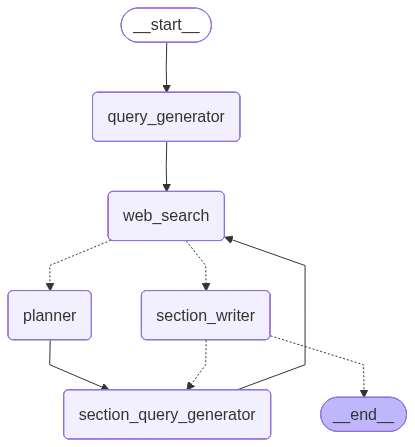

In [20]:
###### Nodes
graph.add_node("query_generator", query_generator)
graph.add_node("web_search", web_search)
graph.add_node("planner", planner)
graph.add_node("section_query_generator", section_query_generator)
graph.add_node("section_writer", section_writer)

##### Edges
graph.add_edge(START, "query_generator")
graph.add_edge("query_generator", "web_search")
graph.add_edge("planner", "section_query_generator")
graph.add_edge("section_query_generator", "web_search")
graph.add_conditional_edges("web_search", web_search_router, {"section_writer": "section_writer", "planner": "planner"})
graph.add_edge("section_writer", END)
graph.add_conditional_edges("section_writer", next_section_router, {END:END, "section_query_generator": "section_query_generator"})
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
compiled_graph = graph.compile(checkpointer=memory)
compiled_graph

#### Invoke Graph and Start Execution

In [21]:
################ Input for generating the report #######################
topic = "Harness Engineering"

In [22]:
inputs = {
    "topic": topic,
    "messages": [
        SystemMessage(content = "You are a researcher assistant, who helps in generating a research report for a given topic."),
        HumanMessage(content = f"Write a Report on research Topic: {topic}")
    ],
    "input_queries": [],
    "execution_stage": 1,
    "sections": [],
    "section_reasoning": [],
    "current_section": -1,
    "report": ""
}

In [23]:
config = {'configurable': {'thread_id': 'research_session_1'}}
for event in compiled_graph.stream(
    inputs, config,
    stream_mode="values"
):
    # print(event)
    event["messages"][-1].pretty_print()
    print(f"Execution stage: {event["execution_stage"]}")

================================ Human Message =================================

Write a Report on research Topic: Harness Engineering
Execution stage: 1
================================== Ai Message ==================================

['What are the key principles of Harness Engineering?', 'How does Harness Engineering differ from traditional engineering disciplines?', 'What are the common applications of Harness Engineering in various industries?', 'What skills and knowledge are essential for a career in Harness Engineering?', 'What are the latest trends and technologies impacting Harness Engineering?']
Execution stage: 1


/var/folders/5n/yqyldx8x7pq7k88nq5xsfpyw0000gn/T/ipykernel_67099/1293849710.py:4: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(


================================== Ai Message ==================================

Searched the web and added queries results to RAG with metadata {'tag': 'all'}
Execution stage: 1
[HumanMessage(content="Decide what sections are going to be in this report about Harness Engineering. Use this context: Query: Query: Query: Query: Query: What are the key principles of Harness Engineering?Answer: of designing and maintaining the control systems that govern how an AI agent perceives its environment, selects actions, and validates outputs. It is distinct from prompt engineering and model selection. The harness is everything that wraps the model: guides that direct the agent, sensors that validate its behavior, and data context pipelines that supply the information it reasons over. What Are the 3 Core Principles of Harness Engineering and How Do You Start? Harness engineering principles are three foundational rules for designing AI systems that are reliable, safe, and improvable.', 'id': 'lc_07

# Final Output Report

In [24]:
os.makedirs("../reports", exist_ok=True)
safe_topic = re.sub(r'[\\/*?:"<>|]', "", topic)
filename = f"../reports/{safe_topic}.md"
final_report = event["report"]
with open(filename, "w", encoding="utf-8") as file:
    file.write(final_report)
